In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load dataset from URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00409/Daily_Demand_Forecasting_Orders.csv"
df = pd.read_csv(url, sep=';')

# --- FIX: Rename the specific target column ---
# The actual column name in the CSV is 'Target (Total orders)'
df.rename(columns={'Target (Total orders)': 'Total Orders'}, inplace=True)

# Create a proper 'Day' index since the data is sequential daily data
df['Day'] = range(1, len(df) + 1)
df.set_index('Day', inplace=True)

print("Dataset Loaded Successfully.")
print(df[['Total Orders']].head())

Dataset Loaded Successfully.
     Total Orders
Day              
1         539.577
2         224.675
3         129.412
4         317.120
5         210.517


Missing Values in 'Total Orders': 0

Summary Statistics:
count     60.000000
mean     300.873317
std       89.602041
min      129.412000
25%      238.195500
50%      288.034500
75%      334.237250
max      616.453000
Name: Total Orders, dtype: float64


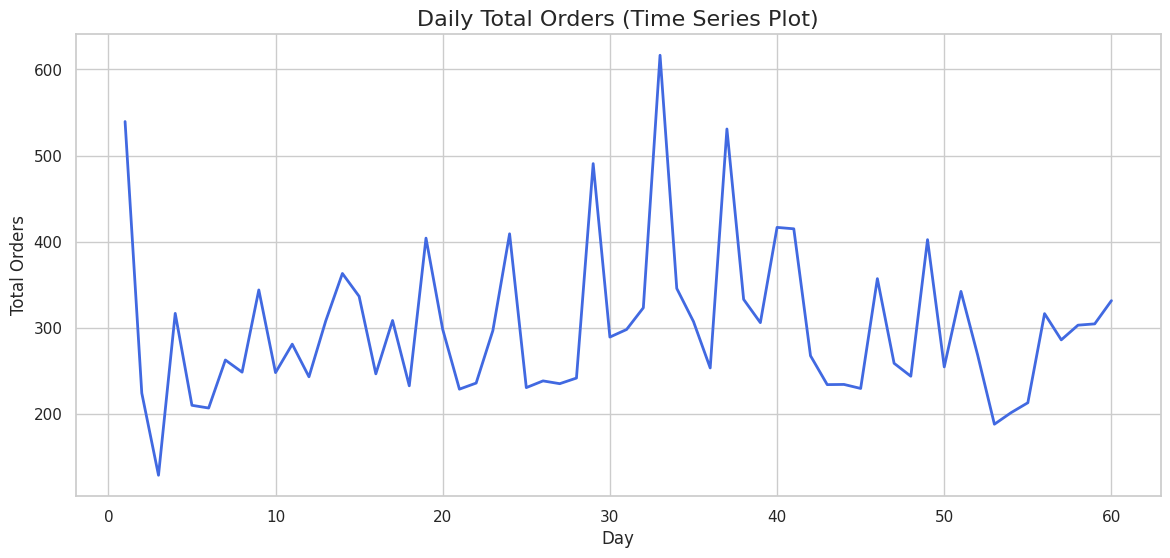

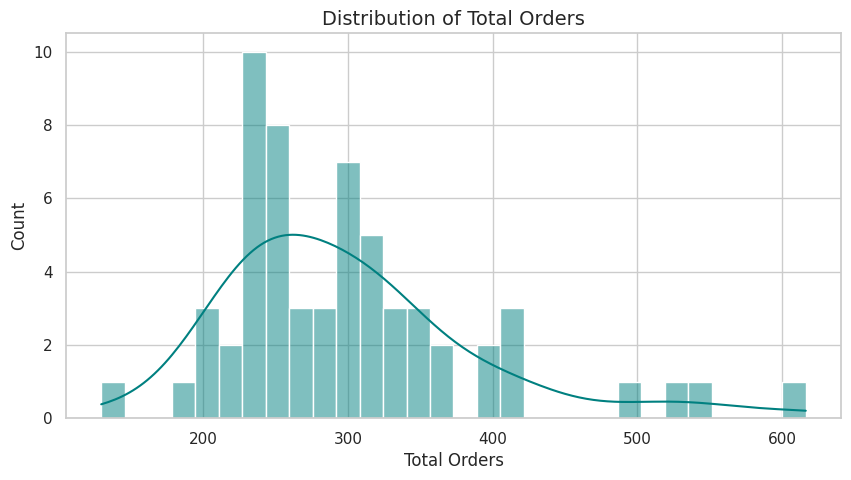

In [4]:
# Task 1: Inspect, Handle Missing Values, and Plot

# 1. Check for missing values
missing_values = df['Total Orders'].isnull().sum()
print(f"Missing Values in 'Total Orders': {missing_values}")

# 2. Fill missing values (if any) using forward fill
if missing_values > 0:
    df['Total Orders'].fillna(method='ffill', inplace=True)
    print("Missing values imputed using Forward Fill.")

# 3. Summary Statistics
print("\nSummary Statistics:")
print(df['Total Orders'].describe())

# 4. Visualization
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='Total Orders', color='royalblue', linewidth=2)
plt.title('Daily Total Orders (Time Series Plot)', fontsize=16)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.show()

# Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(df['Total Orders'], kde=True, color='teal', bins=30)
plt.title('Distribution of Total Orders', fontsize=14)
plt.show()

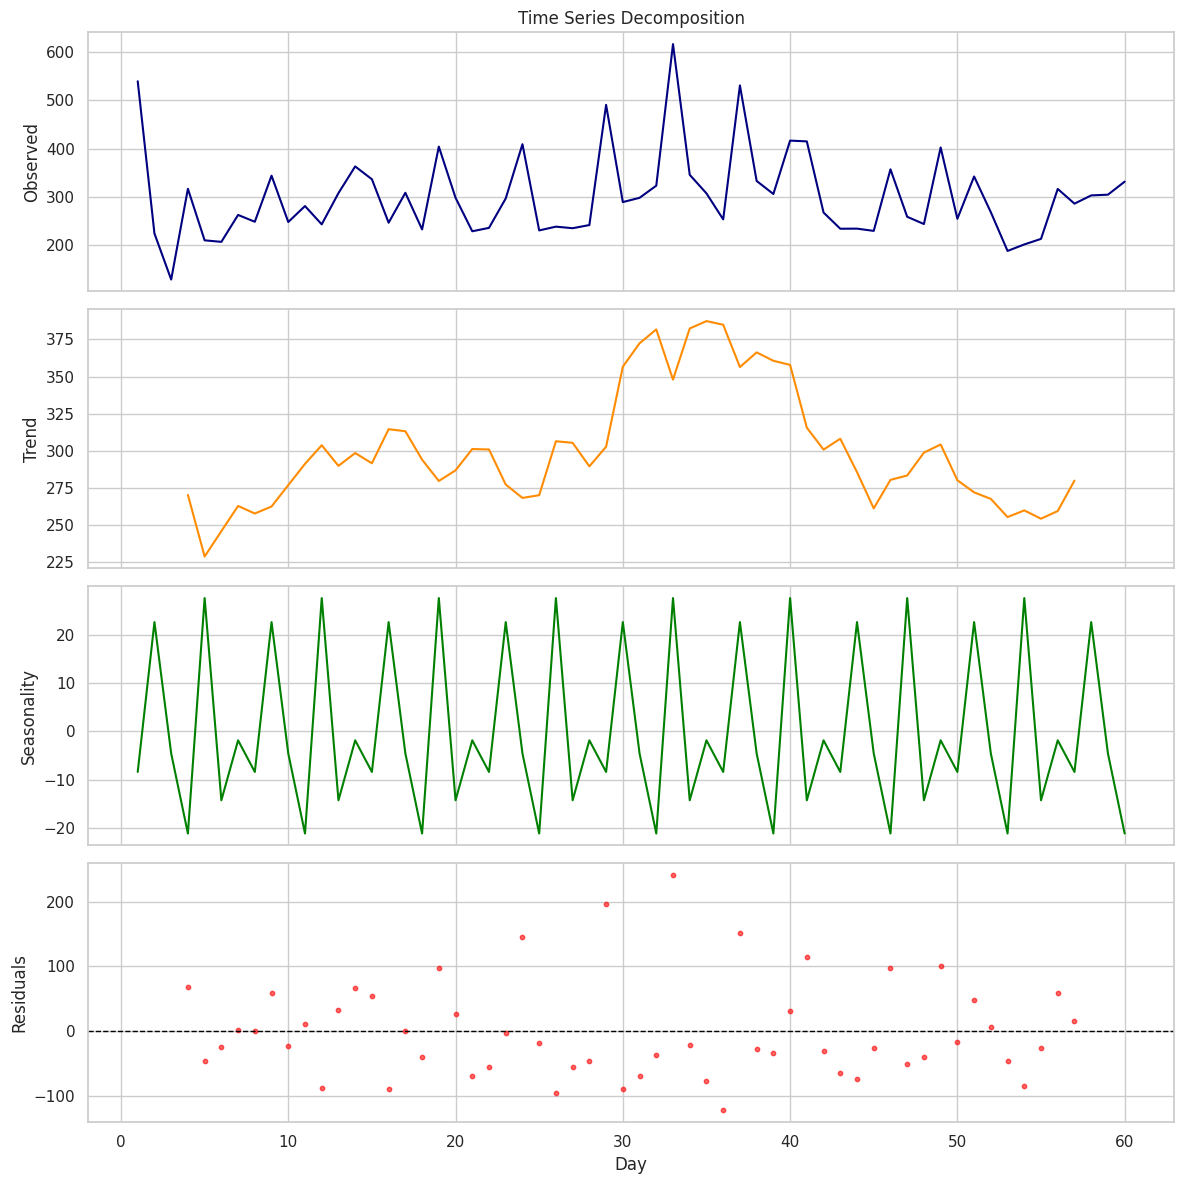

In [5]:
# Task 2: Decompose the series into Trend, Seasonality, and Residuals

# We use an additive model since the amplitude of variations looks relatively constant.
# period=7 implies a weekly seasonality (common for daily data).
decomposition = seasonal_decompose(df['Total Orders'], model='additive', period=7)

# Plotting the decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Original
axes[0].plot(decomposition.observed, color='navy')
axes[0].set_ylabel('Observed')
axes[0].set_title('Time Series Decomposition')

# Trend
axes[1].plot(decomposition.trend, color='darkorange')
axes[1].set_ylabel('Trend')

# Seasonality
axes[2].plot(decomposition.seasonal, color='green')
axes[2].set_ylabel('Seasonality')

# Residuals
axes[3].scatter(df.index, decomposition.resid, color='red', alpha=0.6, s=10)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_ylabel('Residuals')
axes[3].set_xlabel('Day')

plt.tight_layout()
plt.show()

In [6]:
# Task 3: Feature Engineering

# Create a copy to avoid SettingWithCopy warnings
df_features = df[['Total Orders']].copy()

# 1. Lag Features: Capture autocorrelation (Past 1 to 7 days)
for i in range(1, 8):
    df_features[f'Lag_{i}'] = df_features['Total Orders'].shift(i)

# 2. Rolling Statistics: Capture trends and stability
# Rolling Mean (Window = 7 days for weekly trend)
df_features['Rolling_Mean_7'] = df_features['Total Orders'].rolling(window=7).mean()

# Rolling Mean (Window = 30 days for monthly trend)
df_features['Rolling_Mean_30'] = df_features['Total Orders'].rolling(window=30).mean()

# Rolling Standard Deviation (Window = 7 days for volatility)
df_features['Rolling_Std_7'] = df_features['Total Orders'].rolling(window=7).std()

# Drop rows with NaN values created by shifting/rolling
df_features.dropna(inplace=True)

print("Feature Engineering Complete.")
print(df_features.head(10))

Feature Engineering Complete.
     Total Orders    Lag_1    Lag_2    Lag_3    Lag_4    Lag_5    Lag_6  \
Day                                                                       
30        289.657  490.790  242.112  235.598  238.826  231.035  409.401   
31        298.459  289.657  490.790  242.112  235.598  238.826  231.035   
32        323.603  298.459  289.657  490.790  242.112  235.598  238.826   
33        616.453  323.603  298.459  289.657  490.790  242.112  235.598   
34        346.035  616.453  323.603  298.459  289.657  490.790  242.112   
35        307.645  346.035  616.453  323.603  298.459  289.657  490.790   
36        253.847  307.645  346.035  616.453  323.603  298.459  289.657   
37        530.944  253.847  307.645  346.035  616.453  323.603  298.459   
38        333.359  530.944  253.847  307.645  346.035  616.453  323.603   
39        306.356  333.359  530.944  253.847  307.645  346.035  616.453   

       Lag_7  Rolling_Mean_7  Rolling_Mean_30  Rolling_Std_7  
Day   

Training Set Size: 24 rows
Testing Set Size: 7 rows


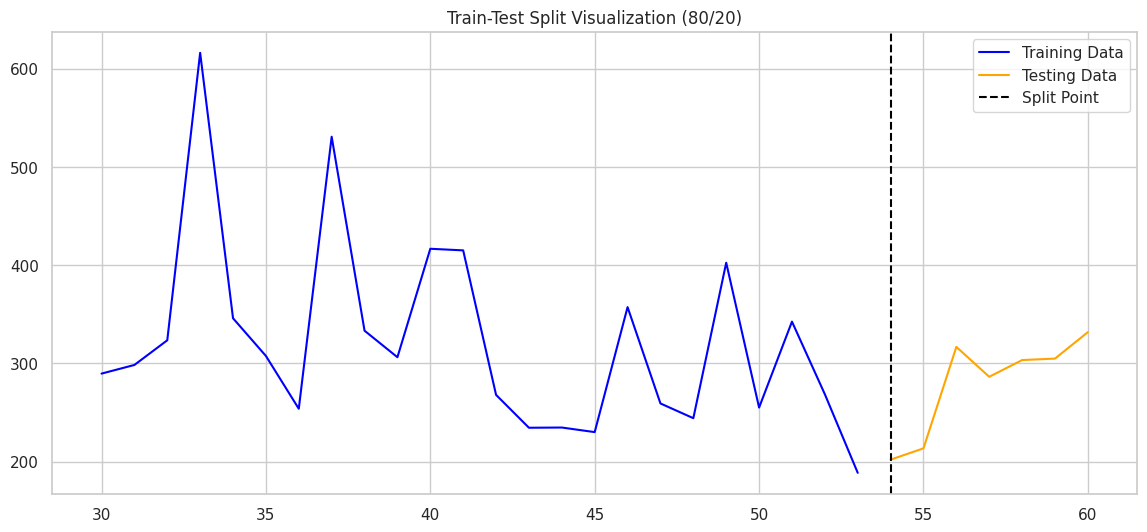

In [7]:
# Task 4: Split the data into Training and Testing sets (Time-based split)

# Define split ratio
train_ratio = 0.80
split_index = int(len(df_features) * train_ratio)

# Split the data
train_data = df_features.iloc[:split_index]
test_data = df_features.iloc[split_index:]

# Separate X (Features) and y (Target)
X_train = train_data.drop(columns=['Total Orders'])
y_train = train_data['Total Orders']

X_test = test_data.drop(columns=['Total Orders'])
y_test = test_data['Total Orders']

print(f"Training Set Size: {len(X_train)} rows")
print(f"Testing Set Size: {len(X_test)} rows")

# Visualizing the Split
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data['Total Orders'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['Total Orders'], label='Testing Data', color='orange')
plt.axvline(x=test_data.index[0], color='black', linestyle='--', label='Split Point')
plt.title('Train-Test Split Visualization (80/20)')
plt.legend()
plt.show()

In [8]:
# Task 5: Initialize and Train Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. Linear Regression (Baseline Model)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model Trained.")

# 2. Random Forest Regressor (Ensemble Model)
# n_estimators=100: Number of trees
# random_state=42: Ensures reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Model Trained.")

# 3. XGBoost Regressor (Gradient Boosting)
# objective='reg:squarederror': Standard for regression tasks
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost Model Trained.")

Linear Regression Model Trained.
Random Forest Model Trained.
XGBoost Model Trained.


In [14]:
# Task 6: Evaluate Model Performance
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_test, y_test, model_name):
    # Make predictions
    predictions = model.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    # Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

    print(f"--- {model_name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print("-" * 30)

    return predictions, rmse

# Evaluate all three models
lr_pred, lr_rmse = evaluate_model(lr_model, X_test, y_test, "Linear Regression")
rf_pred, rf_rmse = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_pred, xgb_rmse = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

--- Linear Regression Performance ---
RMSE: 0.0000
MAE:  0.0000
MAPE: 0.00%
------------------------------
--- Random Forest Performance ---
RMSE: 61.1808
MAE:  45.8587
MAPE: 19.30%
------------------------------
--- XGBoost Performance ---
RMSE: 82.2130
MAE:  69.6418
MAPE: 26.15%
------------------------------


In [10]:
# Task 7: Hyperparameter Tuning (using GridSearchCV on Random Forest)
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,                # 3-fold cross-validation
                           n_jobs=-1,           # Use all available CPU cores
                           scoring='neg_mean_squared_error',
                           verbose=1)

# Fit to training data
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# Get the best model
best_rf_model = grid_search.best_estimator_

print("\nBest Parameters found:")
print(grid_search.best_params_)

# Evaluate the tuned model
tuned_rf_pred, tuned_rf_rmse = evaluate_model(best_rf_model, X_test, y_test, "Tuned Random Forest")

Starting Grid Search...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best Parameters found:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
--- Tuned Random Forest Performance ---
RMSE: 60.3214
MAE:  45.2138
MAPE: 19.15%
------------------------------


In [13]:
# Task 8: Generate Final Forecasts on Test Data

# Create a DataFrame to compare Actual vs Predicted values
comparison_df = pd.DataFrame({
    'Date': test_data.index,
    'Actual': y_test,
    'Predicted': tuned_rf_pred
})

# Calculate the error (Residuals)
comparison_df['Error'] = comparison_df['Actual'] - comparison_df['Predicted']

print("Forecast vs Actual (First 5 Rows):")
print(comparison_df.head())

# Save forecasts to CSV (optional)
comparison_df.to_csv('Forecast_Results.csv', index=False)
print("\nForecast results saved to 'Forecast_Results.csv'")

Forecast vs Actual (First 5 Rows):
     Date   Actual   Predicted       Error
Day                                       
54     54  202.022  334.249112 -132.227112
55     55  213.509  280.794360  -67.285360
56     56  316.849  282.969077   33.879923
57     57  286.412  294.526347   -8.114347
58     58  303.447  281.662066   21.784934

Forecast results saved to 'Forecast_Results.csv'


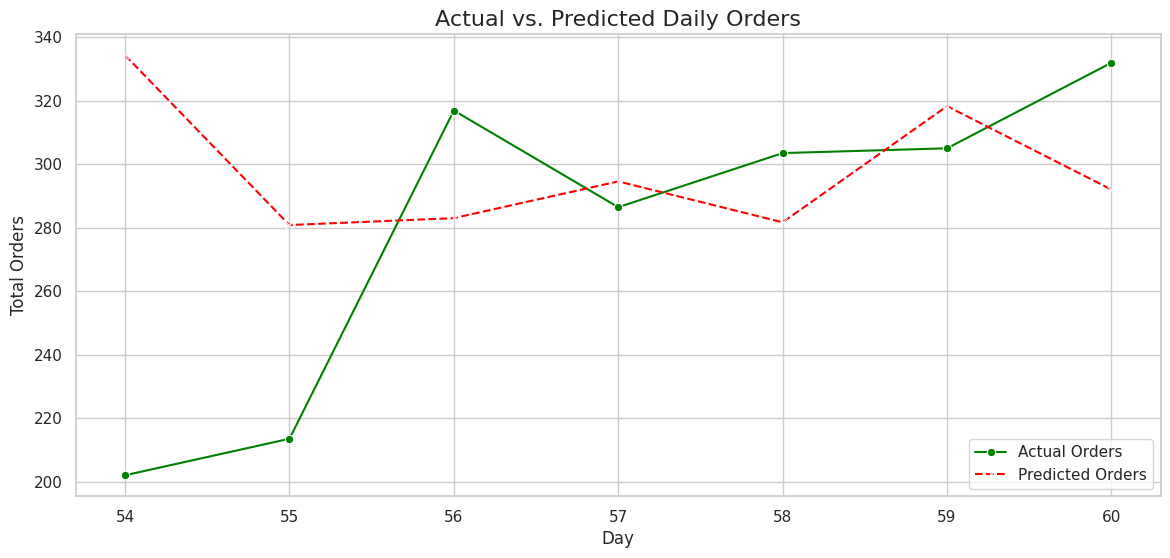

In [15]:
# Task 9: Visualize Final Forecasts

plt.figure(figsize=(14, 6))
sns.lineplot(data=comparison_df, x='Date', y='Actual', label='Actual Orders', color='green', marker='o')
sns.lineplot(data=comparison_df, x='Date', y='Predicted', label='Predicted Orders', color='red', linestyle='--', marker='x')
plt.title('Actual vs. Predicted Daily Orders', fontsize=16)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()